🔴 RISK LAYER 5: LICENSE VALIDATION

Purpose: Identify declared licenses without proper authorization
Regulatory Basis: EAR Licensing Requirements

📦 Analyzing 5,000 shipments...

📊 RESULTS:
   ┌─ Shipments declaring license/exception: 2,782
   ├─ Missing license (Skipped Validation): 451
   ├─ License Compliance Rate: 83.79%
   ├─ Overall Defect Rate: 9.02%
   ├─ Total Value at Risk: $304,260,424.27
   └─ Average Value per Failure: $674,635.09

🔍 SAMPLE LICENSE FAILURES:

   ┌─ Shipment: EXP-100015
   ├─ License Type: EXCEPTION (Declared)
   ├─ License Obtained: N (No)
   ├─ Business Unit: US-ConsumerElectronics
   ├─ Destination: CRIMEA
   ├─ ECCN: EAR99
   └─ Value: $798,554.25

   ┌─ Shipment: EXP-100035
   ├─ License Type: LICENSE (Declared)
   ├─ License Obtained: N (No)
   ├─ Business Unit: US-AerospaceParts
   ├─ Destination: SG
   ├─ ECCN: 5A002
   └─ Value: $417,979.80

   ┌─ Shipment: EXP-100042
   ├─ License Type: EXCEPTION (Declared)
   ├─ License Obtained: N (No)
   ├─ Bus

,Business Unit,Total Shipments,License Failures,Total Value,Failure Rate %
4,US-Pharmaceuticals,478,48,2.948135e+08,10.04
2,US-IndustrialEquipment,966,95,6.082091e+08,9.83
0,US-AerospaceParts,735,71,4.713519e+08,9.66
3,US-MedicalDevices,1239,111,8.121318e+08,8.96
1,US-ConsumerElectronics,1582,126,9.824572e+08,7.96



📊 LICENSE FAILURES BY LICENSE TYPE:


,License Type,Total Shipments,License Failures,Total Value,Failure Rate %
1,LICENSE,1789,298,1.110836e+09,16.66
0,EXCEPTION,993,153,6.404965e+08,15.41
2,NLR,2218,0,1.417631e+09,0.00



📊 LICENSE FAILURES BY DESTINATION COUNTRY:


,Country,License Failures,Total Value
3,IE,65,49086998.09
11,TW,64,41708024.40
0,BE,62,35611067.17
6,MX,52,37488465.93
8,SA,50,35174276.31
1,CN,49,35825282.80
9,SG,49,28333700.82
4,IN,48,27001490.71
2,CRIMEA,4,3218122.43
5,IRAN,4,5436070.16



📅 MONTHLY LICENSE FAILURE RATE:


,License_Failures,Total_Shipments,License_Failure_Rate_Pct
shipment_month,,,
2025-07,31,349,8.88
2025-08,30,415,7.23
2025-09,35,401,8.73
2025-10,43,433,9.93
2025-11,35,430,8.14
2025-12,50,465,10.75
2026-01,38,384,9.90
2026-02,30,395,7.59
2026-03,31,402,7.71



📈 RECENT TREND (Last 6 months):
   2026-02:  7.59% ███████████████
   2026-03:  7.71% ███████████████
   2026-04: 10.50% █████████████████████
   2026-05:  9.95% ███████████████████
   2026-06:  6.91% █████████████
   2026-07: 16.13% ████████████████████████████████


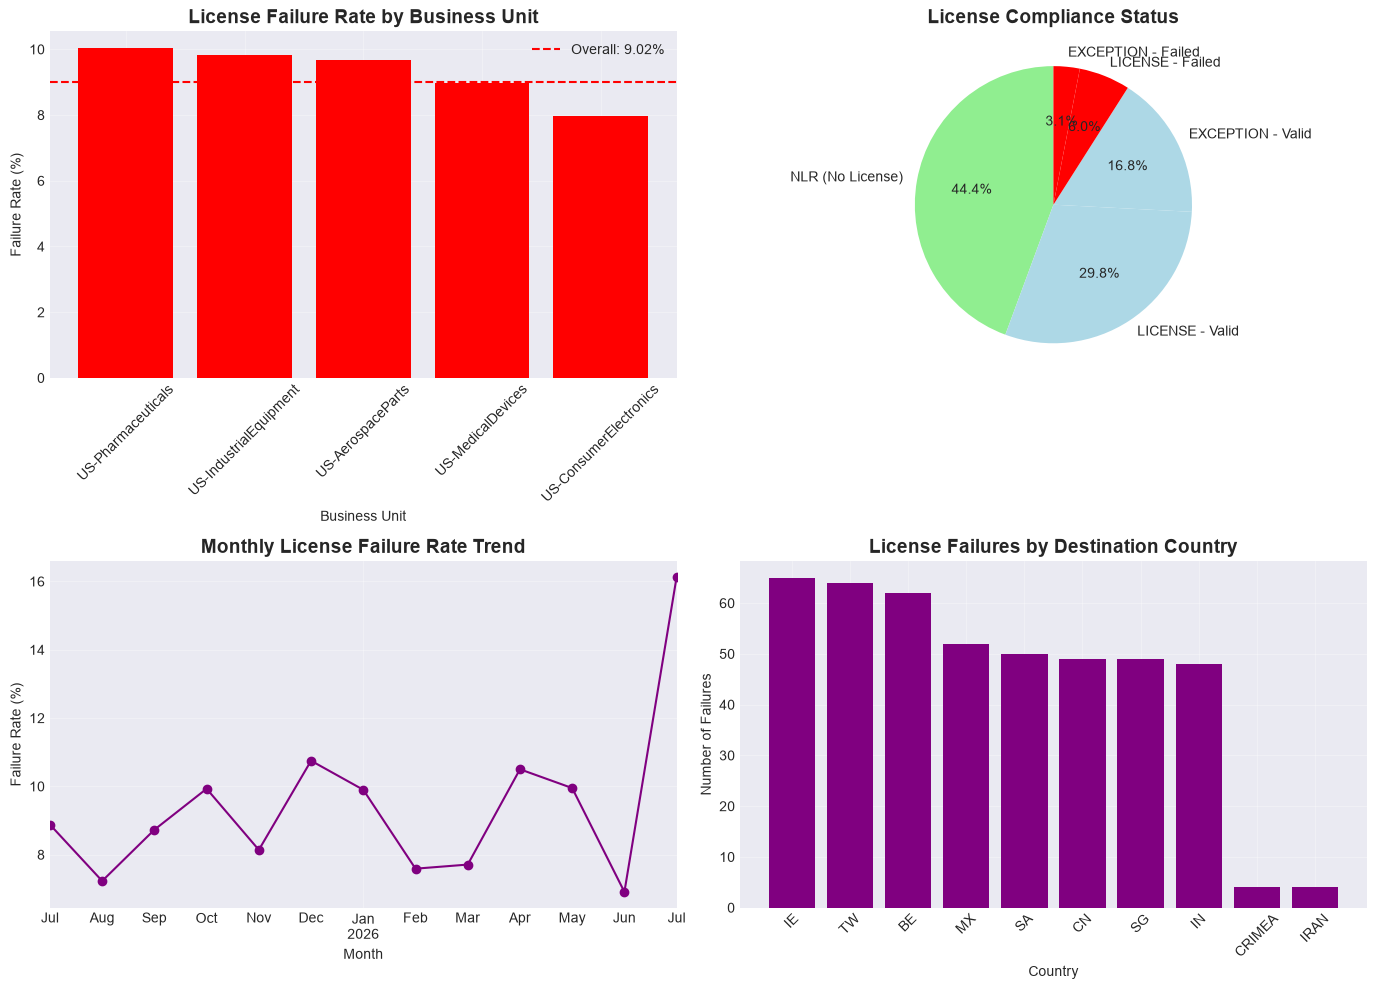


💾 Saved: output/risk_layer5_license_validation.png

💾 Saved: us_export_compliance_data_with_risk.csv

✅ RISK LAYER 5 COMPLETE!


In [2]:
# %% [markdown]
# # 🔴 Risk Layer 5: License Validation
# 
# **Purpose**: Identify declared licenses without proper authorization
# 
# **Regulatory Basis**: EAR Licensing Requirements
# 
# **Key Question**: Are we declaring licenses we haven't actually obtained?

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("🔴 RISK LAYER 5: LICENSE VALIDATION")
print("="*70)
print("\nPurpose: Identify declared licenses without proper authorization")
print("Regulatory Basis: EAR Licensing Requirements")

# %% [code]
# Load dataset with previous layers
df = pd.read_csv('us_export_compliance_data_layer4.csv', parse_dates=['shipment_date', 'clearance_date'])

print(f"\n📦 Analyzing {len(df):,} shipments...")

# %% [markdown]
# ## License Validation Logic
# 
# **Rule**: If you declare a license type (LICENSE or EXCEPTION), you must have the license
# - `license_type in ['LICENSE', 'EXCEPTION']` (License declared)
# - `license_obtained == 'N'` (License not obtained)

# %% [code]
# Apply license validation logic
df['license_validation_failure'] = (
    (df['license_type'].isin(['LICENSE', 'EXCEPTION'])) & 
    (df['license_obtained'] == 'N')
)

# Count results
license_failures = df['license_validation_failure'].sum()
license_failure_rate = (license_failures / len(df)) * 100
license_declared_count = len(df[df['license_type'].isin(['LICENSE', 'EXCEPTION'])])
license_compliance_rate = ((license_declared_count - license_failures) / license_declared_count * 100) if license_declared_count > 0 else 0
license_total_value = df[df['license_validation_failure']]['total_value_usd'].sum()
license_avg_value = df[df['license_validation_failure']]['total_value_usd'].mean()

print(f"\n📊 RESULTS:")
print(f"   ┌─ Shipments declaring license/exception: {license_declared_count:,}")
print(f"   ├─ Missing license (Skipped Validation): {license_failures:,}")
print(f"   ├─ License Compliance Rate: {license_compliance_rate:.2f}%")
print(f"   ├─ Overall Defect Rate: {license_failure_rate:.2f}%")
print(f"   ├─ Total Value at Risk: ${license_total_value:,.2f}")
print(f"   └─ Average Value per Failure: ${license_avg_value:,.2f}")

# %% [markdown]
# ## Examine License Failures

# %% [code]
if license_failures > 0:
    print("\n🔍 SAMPLE LICENSE FAILURES:")
    sample_license = df[df['license_validation_failure']][
        ['shipment_id', 'license_type', 'license_obtained', 
         'exporter_business_unit', 'consignee_country', 'eccn', 'total_value_usd']
    ].head(5)
    
    for idx, row in sample_license.iterrows():
        print(f"\n   ┌─ Shipment: {row['shipment_id']}")
        print(f"   ├─ License Type: {row['license_type']} (Declared)")
        print(f"   ├─ License Obtained: {row['license_obtained']} (No)")
        print(f"   ├─ Business Unit: {row['exporter_business_unit']}")
        print(f"   ├─ Destination: {row['consignee_country']}")
        print(f"   ├─ ECCN: {row['eccn']}")
        print(f"   └─ Value: ${row['total_value_usd']:,.2f}")

# %% [markdown]
# ## Analysis by Business Unit

# %% [code]
license_by_bu = df.groupby('exporter_business_unit').agg({
    'shipment_id': 'count',
    'license_validation_failure': 'sum',
    'total_value_usd': 'sum'
}).reset_index()

license_by_bu.columns = ['Business Unit', 'Total Shipments', 'License Failures', 'Total Value']
license_by_bu['Failure Rate %'] = (license_by_bu['License Failures'] / license_by_bu['Total Shipments'] * 100).round(2)
license_by_bu = license_by_bu.sort_values('Failure Rate %', ascending=False)

print("\n📊 LICENSE FAILURES BY BUSINESS UNIT:")
display(license_by_bu)

# %% [markdown]
# ## Analysis by License Type

# %% [code]
license_type_analysis = df.groupby('license_type').agg({
    'shipment_id': 'count',
    'license_validation_failure': 'sum',
    'total_value_usd': 'sum'
}).reset_index()

license_type_analysis.columns = ['License Type', 'Total Shipments', 'License Failures', 'Total Value']
license_type_analysis['Failure Rate %'] = (license_type_analysis['License Failures'] / license_type_analysis['Total Shipments'] * 100).round(2)
license_type_analysis = license_type_analysis.sort_values('Failure Rate %', ascending=False)

print("\n📊 LICENSE FAILURES BY LICENSE TYPE:")
display(license_type_analysis)

# %% [markdown]
# ## Analysis by Destination Country

# %% [code]
license_by_country = df[df['license_validation_failure']].groupby('consignee_country').agg({
    'shipment_id': 'count',
    'total_value_usd': 'sum'
}).reset_index()

license_by_country.columns = ['Country', 'License Failures', 'Total Value']
license_by_country = license_by_country.sort_values('License Failures', ascending=False)

print("\n📊 LICENSE FAILURES BY DESTINATION COUNTRY:")
display(license_by_country.head(10))

# %% [markdown]
# ## Time-Based Analysis

# %% [code]
# Monthly license failure rate
df['shipment_month'] = df['shipment_date'].dt.to_period('M')
monthly_license = df.groupby('shipment_month').agg({
    'license_validation_failure': ['sum', 'count']
}).round(4)

monthly_license.columns = ['License_Failures', 'Total_Shipments']
monthly_license['License_Failure_Rate_Pct'] = (monthly_license['License_Failures'] / monthly_license['Total_Shipments'] * 100).round(2)

print("\n📅 MONTHLY LICENSE FAILURE RATE:")
display(monthly_license)

# Show trend
print("\n📈 RECENT TREND (Last 6 months):")
for month, row in monthly_license.tail(6).iterrows():
    rate = row['License_Failure_Rate_Pct']
    bar = '█' * int(rate * 2)
    print(f"   {month}: {rate:5.2f}% {bar}")

# %% [markdown]
# ## Visualization

# %% [code]
# Create output folder if it doesn't exist
if not os.path.exists('output'):
    os.makedirs('output')
    print("✅ Created output folder")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. License failure rate by business unit
bu_license_sorted = license_by_bu.sort_values('Failure Rate %', ascending=False)
colors = ['red' if rate > 1 else 'orange' if rate > 0.5 else 'green' for rate in bu_license_sorted['Failure Rate %']]
axes[0,0].bar(bu_license_sorted['Business Unit'], bu_license_sorted['Failure Rate %'], color=colors)
axes[0,0].set_title('License Failure Rate by Business Unit', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Business Unit')
axes[0,0].set_ylabel('Failure Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=license_failure_rate, color='red', linestyle='--', 
                  label=f'Overall: {license_failure_rate:.2f}%')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. License status distribution
license_status = df.groupby('license_type')['license_validation_failure'].sum()
license_labels = ['NLR (No License)', 'LICENSE - Valid', 'EXCEPTION - Valid', 'LICENSE - Failed', 'EXCEPTION - Failed']
license_values = [
    len(df[df['license_type'] == 'NLR']),
    len(df[(df['license_type'] == 'LICENSE') & (df['license_validation_failure'] == False)]),
    len(df[(df['license_type'] == 'EXCEPTION') & (df['license_validation_failure'] == False)]),
    len(df[(df['license_type'] == 'LICENSE') & (df['license_validation_failure'] == True)]),
    len(df[(df['license_type'] == 'EXCEPTION') & (df['license_validation_failure'] == True)])
]
colors_pie = ['lightgreen', 'lightblue', 'lightblue', 'red', 'red']
# Only show if values exist
valid_pie_labels = []
valid_pie_values = []
valid_pie_colors = []
for label, value, color in zip(license_labels, license_values, colors_pie):
    if value > 0:
        valid_pie_labels.append(label)
        valid_pie_values.append(value)
        valid_pie_colors.append(color)
axes[0,1].pie(valid_pie_values, labels=valid_pie_labels, autopct='%1.1f%%', colors=valid_pie_colors, startangle=90)
axes[0,1].set_title('License Compliance Status', fontsize=14, fontweight='bold')

# 3. Monthly trend
monthly_license['License_Failure_Rate_Pct'].plot(kind='line', ax=axes[1,0], marker='o', color='purple')
axes[1,0].set_title('Monthly License Failure Rate Trend', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Failure Rate (%)')
axes[1,0].grid(True, alpha=0.3)

# 4. License failures by destination country (top 10)
license_country_sorted = license_by_country.head(10)
axes[1,1].bar(license_country_sorted['Country'], license_country_sorted['License Failures'], color='purple')
axes[1,1].set_title('License Failures by Destination Country', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Country')
axes[1,1].set_ylabel('Number of Failures')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/risk_layer5_license_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Saved: output/risk_layer5_license_validation.png")

# %% [code]
# Save the enhanced dataset
df.to_csv('us_export_compliance_data_with_risk.csv', index=False)
print("\n💾 Saved: us_export_compliance_data_with_risk.csv")

print("\n" + "="*70)
print("✅ RISK LAYER 5 COMPLETE!")
print("="*70)